In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import seaborn as sns

In [64]:
df = pd.read_csv('/Users/elzaniyazbekova/Desktop/MLLM/diabetes_risk.csv')
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [65]:
df.shape

(15000, 19)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

| Column                     | Type       | Обоснование                                                                 |
| -------------------------- | ---------- | --------------------------------------------------------------------------- |
| `patient_id`| Discrete   | separate integer values |
| `age`| Discrete   | whole years|
| `gender`| Nominal| no  order|
| `city`| Nominal    | no order|
| `bmi| Continuous | decimal values |
| `family_history_diabetes`| Nominal    | no order|
| `physical_activity_level`| Ordinal    | Sedentary < Moderate < Active|
| `diet_type`| Nominal| no order|
| `smoking_status`| Nominal| Never/Current/Former categories|
| `alcohol_consumption`| Ordinal| Never < Occasional < Regular|
| `hours_sleep_per_night`| Continuous |range of values|
| `stress_level`| Ordinal| categories|
| `fasting_blood_sugar`| Continuous | range of values|
| `hba1c_level`| Continuous |range of values|
| `blood_pressure_systolic`| Continuous |range of values|
| `blood_pressure_diastolic`| Continuous | range of values|
| `waist_circumference_cm`| Continuous |range of values|
| `income_bracket`| Ordinal    | Low < Middle < High|
| `diabetes_risk`| Ordinal    | Low < Moderate < High|


In [67]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].head()

mean = df[num_cols].mean()
median = df[num_cols].median()
mode = df[num_cols].mode().iloc[0]
range1 = df[num_cols].max()-df[num_cols].min()
variance = df[num_cols].var()
std = df[num_cols].std()
IQR = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)

ctd = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Mode': mode,
    'Range': range1,
    'Variance': variance,
    'Std Dev': std,
    'IQR': IQR
})

ctd

,Mean,Median,Mode,Range,Variance,Std Dev,IQR
patient_id,7500.500000,7500.5,1.0,14999.0,1.875125e+07,4330.271354,7499.5
age,44.333667,45.0,47.0,62.0,1.078223e+02,10.383753,14.0
bmi,23.062260,22.7,21.6,25.8,1.637328e+01,4.046391,5.5
hours_sleep_per_night,7.309860,7.0,7.0,9.0,1.230707e+00,1.109372,1.3
stress_level,5.941200,6.0,6.0,9.0,4.615650e+00,2.148406,3.0
fasting_blood_sugar,168.789933,165.0,164.0,328.0,1.471936e+03,38.365822,44.0
hba1c_level,6.878387,6.8,6.7,8.6,7.111149e-01,0.843276,1.0
blood_pressure_systolic,139.496200,140.0,140.0,120.0,1.602955e+02,12.660785,20.0
blood_pressure_diastolic,86.256933,88.0,80.0,70.0,7.033387e+01,8.386529,10.0
waist_circumference_cm,100.207933,99.3,96.1,75.0,1.157847e+02,10.760331,14.4


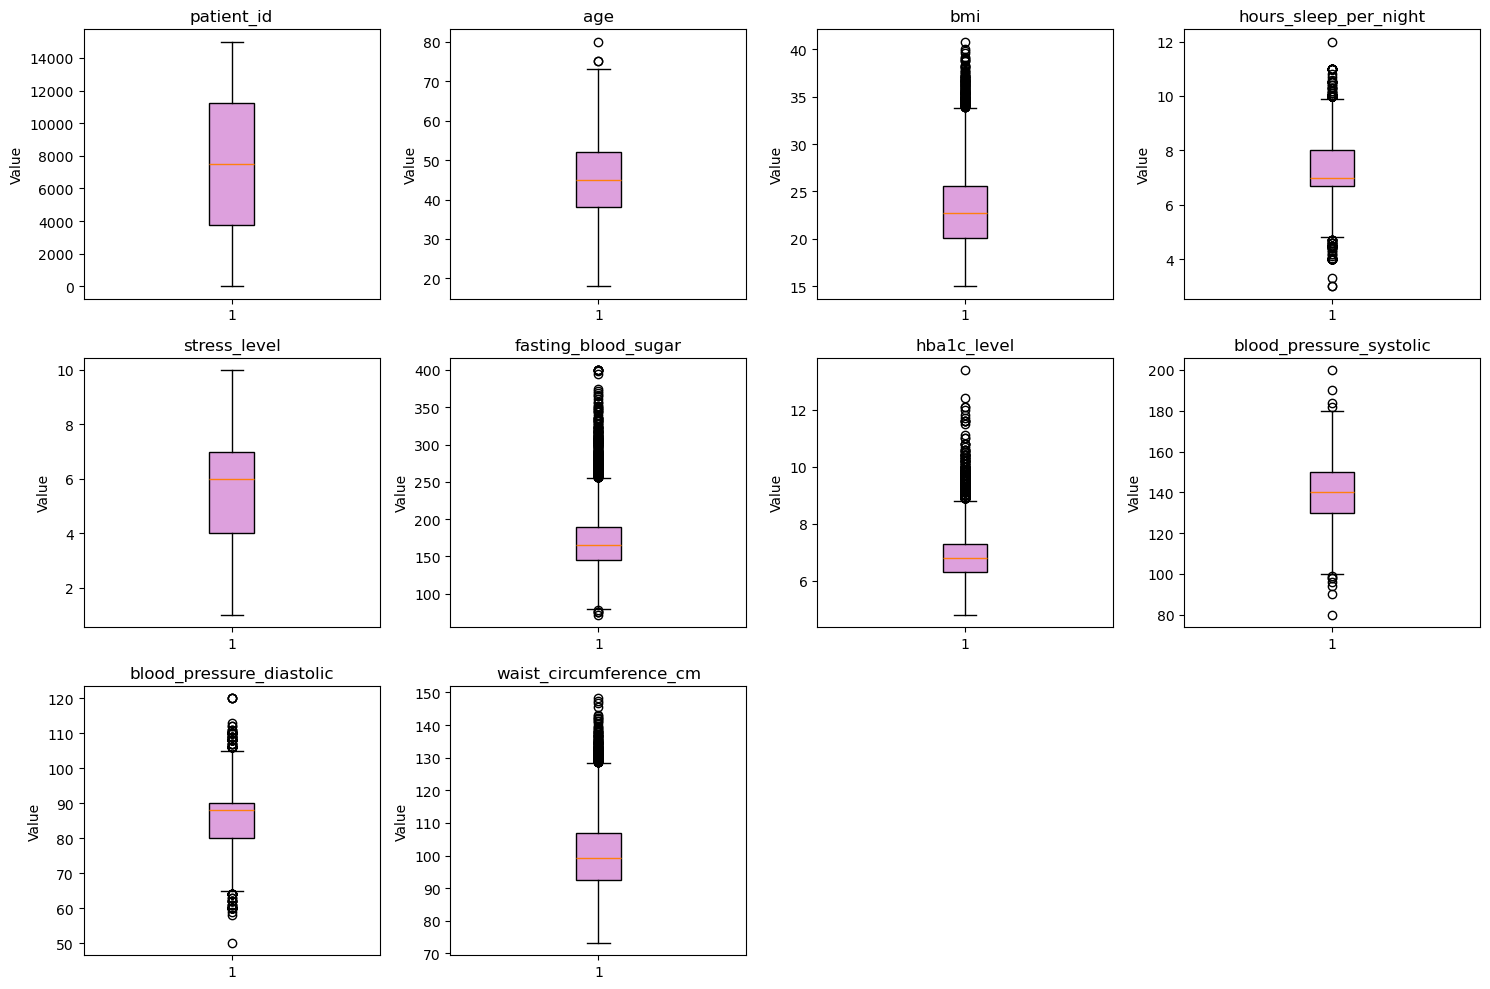

In [68]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):

    plt.subplot(3, 4, i + 1)

    plt.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='plum'))

    plt.title(col)

    plt.ylabel("Value")

plt.tight_layout()

plt.show()

In [69]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_anomaly = (
        (df[num_cols] < lower_bound) |
        (df[num_cols] > upper_bound)
    )
print(iqr_anomaly.sum())

patient_id                    0
age                           3
bmi                         153
hours_sleep_per_night       360
stress_level                  0
fasting_blood_sugar         432
hba1c_level                 355
blood_pressure_systolic      11
blood_pressure_diastolic    213
waist_circumference_cm      167
dtype: int64


In [70]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

In [71]:
print(df['income_bracket'].isna().sum())

463


In [72]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression


df['income_bracket'] = df['income_bracket'].replace({'High': 1, 'Middle': 2, 'Low': 3})
imputer = SimpleImputer(strategy='constant', fill_value = 'Unknown')

df[['smoking_status']] = imputer.fit_transform(df[['smoking_status']])

df['alcohol_consumption'] =df['alcohol_consumption'].fillna(df['alcohol_consumption'].mode()[0])

train = df[df['income_bracket'].notna()]
missing = df[df['income_bracket'].isna()]
model = LinearRegression()

model.fit(
    train[['age', 'bmi']],
    train['income_bracket']
)

predicted = model.predict(
    missing[['age', 'bmi']]
)

predicted = predicted.round().clip(1, 3)

df.loc[df['income_bracket'].isna(), 'income_bracket'] = predicted


/var/folders/fr/z_dfth2j59d9x0yb0cqqj8lm0000gn/T/ipykernel_2863/1025322665.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income_bracket'] = df['income_bracket'].replace({'High': 1, 'Middle': 2, 'Low': 3})


In [73]:
df.isnull().sum()

patient_id                  0
age                         0
gender                      0
city                        0
bmi                         0
family_history_diabetes     0
physical_activity_level     0
diet_type                   0
smoking_status              0
alcohol_consumption         0
hours_sleep_per_night       0
stress_level                0
fasting_blood_sugar         0
hba1c_level                 0
blood_pressure_systolic     0
blood_pressure_diastolic    0
waist_circumference_cm      0
income_bracket              0
diabetes_risk               0
dtype: int64

In [74]:
std_a = df[num_cols].std()
mean_a = df[num_cols].mean()
print(std_a, mean_a)

patient_id                  4330.271354
age                           10.383753
bmi                            4.046391
hours_sleep_per_night          1.109372
stress_level                   2.148406
fasting_blood_sugar           38.365822
hba1c_level                    0.843276
blood_pressure_systolic       12.660785
blood_pressure_diastolic       8.386529
waist_circumference_cm        10.760331
dtype: float64 patient_id                  7500.500000
age                           44.333667
bmi                           23.062260
hours_sleep_per_night          7.309860
stress_level                   5.941200
fasting_blood_sugar          168.789933
hba1c_level                    6.878387
blood_pressure_systolic      139.496200
blood_pressure_diastolic      86.256933
waist_circumference_cm       100.207933
dtype: float64


In [75]:
print(std, mean)

patient_id                  4330.271354
age                           10.383753
bmi                            4.046391
hours_sleep_per_night          1.109372
stress_level                   2.148406
fasting_blood_sugar           38.365822
hba1c_level                    0.843276
blood_pressure_systolic       12.660785
blood_pressure_diastolic       8.386529
waist_circumference_cm        10.760331
dtype: float64 patient_id                  7500.500000
age                           44.333667
bmi                           23.062260
hours_sleep_per_night          7.309860
stress_level                   5.941200
fasting_blood_sugar          168.789933
hba1c_level                    6.878387
blood_pressure_systolic      139.496200
blood_pressure_diastolic      86.256933
waist_circumference_cm       100.207933
dtype: float64


# 2 Level B — Medium


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

standard = StandardScaler()
minmax = MinMaxScaler()
dfs = df.copy()

dfs[num_cols] = scaler_std.fit_transform(dfs[num_cols])